In [67]:
cd ..

d:\Physics\lensing-project


In [68]:
cd data

d:\Physics\lensing-project\data


(0.0, 10.0)

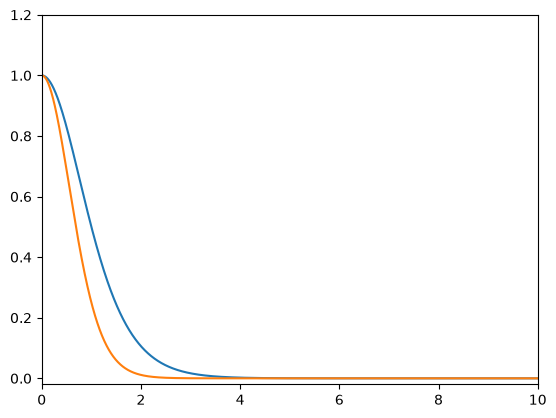

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

file_sh = 'Perfil_radialn0.npz'
#file_sh = 'Perfil_linealn0.npz'
data_sh = np.load(file_sh)
rho_sh = data_sh['perfil']**2
#UProca_sh = data_sh['potencial']
rad_sh = data_sh['radio']

plt.plot(rad_sh, np.sqrt(rho_sh))
plt.plot(rad_sh, rho_sh)
plt.ylim(-0.02, 1.2)
plt.xlim(0.0, 10)

In [4]:
print(rad_sh.min(), rad_sh.max())
print(rho_sh.min(), rho_sh.max())

0.0 79.47913000000001
1.952815872050562e-17 1.0


In [ ]:
plt.figure(figsize=(6,4))
plt.plot(rad_sh, UProca_sh)
plt.xlabel(r"$r$")
plt.ylabel(r"$V_{\rm eff}$")
plt.grid()

In [5]:
print(data_sh.files)
print(data_sh['perfil'][:10])
print(data_sh['perfil'].min(), data_sh['perfil'].max())

['perfil', 'potencial', 'radio']
[1.         0.99999996 0.99999992 0.99999988 0.99999984 0.9999998
 0.99999976 0.99999972 0.99999968 0.99999964]
4.419067630225365e-09 1.0


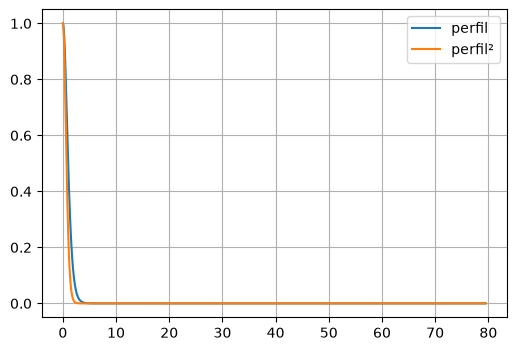

In [5]:
plt.figure(figsize=(6,4))

plt.plot(rad_sh, data_sh['perfil'], label='perfil')
plt.plot(rad_sh, data_sh['perfil']**2, label='perfil²')

plt.legend()
plt.grid()

C:\Users\SEARS\AppData\Local\Temp\ipykernel_4756\142431893.py:49: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_restricted, _ = curve_fit(model_restricted, r, perfil, p0=[1,1,1,-1], maxfev=20000)


=========== ANALISIS DE AJUSTE ===========

--- Exponencial ---
MSE  = 0.0002536762506268569
RMSE = 0.01592721729075286
R²   = 0.9661441907389857

--- Gaussiano ---
MSE  = 8.016236819301097e-06
RMSE = 0.002831295961092923
R²   = 0.9989301474455148

--- General ---
MSE  = 1.1024647265005528e-06
RMSE = 0.0010499832029611487
R²   = 0.9998528642890094

--- Restricted ---
MSE  = 4.1008628640355573e-07
RMSE = 0.0006403797985598513
R²   = 0.9999452695983218

=========== PARAMETROS ===========

Exponencial:
A = 2.845057055923765
b = 1.513211140178606

Gaussiano:
A = 1.3829634838459328
b = 0.6271635040784326

General:
A = 1.7395160926018174
b = 0.8699903624238194
n = 1.1182515610661141
m = 1.6712382449934584

Restricted:
A = 1.4438899853210703
b = 3.999355883016764
n = 1.0
m = -11.244140912027522



d:\Physics\lensing-project\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


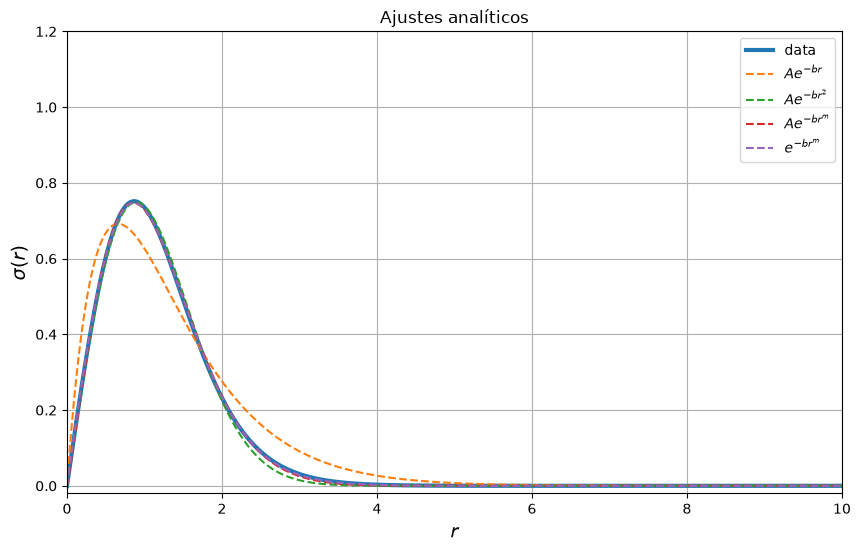

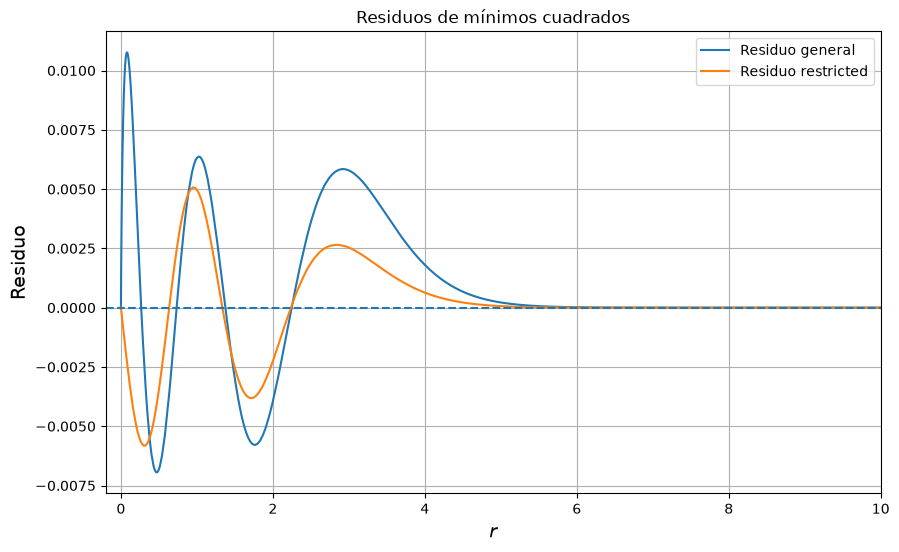

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad

# ============================================================
# CARGAR DATOS
# ============================================================

lambd=1
file_sh = 'Perfil_radialn0.npz'
#file_sh = 'Perfil_linealn0.npz'
data_sh = np.load(file_sh)

r = lambd**(-1/2)*data_sh["radio"]
perfil = lambd*data_sh["perfil"]
RMAX_CUT = r.max()

# ============================================================
# MODELOS
# ============================================================
# Se retira el factor *r
def model_exp(r, A, b):
    return A *r* np.exp(-b*r)
    #return A * np.exp(-b*r)

def model_gauss(r, A, b):
    return A *r* np.exp(-b*r**2)
    #return A * np.exp(-b*r**2)

def model_general(r, A, b, n, m):
    return A  * r**n * np.exp(-b*r**m)
    #return A * np.exp(-b*r**m)

def model_restricted(r, A, b, n, m):
    #return np.exp(-(r/b)**m)
    return A * r * (1 + (r / b)**2)**m

# ============================================================
# AJUSTES
# ============================================================

popt_exp, _ = curve_fit(model_exp, r, perfil, p0=[1,1])

popt_gauss, _ = curve_fit(model_gauss, r, perfil, p0=[1,1])

popt_general, _ = curve_fit(model_general, r, perfil, p0=[1,1,1,2], maxfev=20000)

popt_restricted, _ = curve_fit(model_restricted, r, perfil, p0=[1,1,1,-1], maxfev=20000)

# ============================================================
# CURVAS AJUSTADAS
# ============================================================

fit_exp = model_exp(r, *popt_exp)

fit_gauss = model_gauss(r, *popt_gauss)

fit_general = model_general(r, *popt_general)

fit_restricted = model_restricted(r, *popt_restricted)

# ============================================================
# ANALISIS DE MINIMOS CUADRADOS
# ============================================================

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - ss_res/ss_tot

# ============================================================
# RESULTADOS
# ============================================================

print("=========== ANALISIS DE AJUSTE ===========\n")

models = {
    "Exponencial": fit_exp,
    "Gaussiano": fit_gauss,
    "General": fit_general,
    "Restricted": fit_restricted
}

for name, fit in models.items():

    print(f"--- {name} ---")

    print("MSE  =", mse(perfil, fit))
    print("RMSE =", rmse(perfil, fit))
    print("R²   =", r2_score(perfil, fit))

    print()

# ============================================================
# PARAMETROS
# ============================================================

print("=========== PARAMETROS ===========\n")

print("Exponencial:")
print(f"A = {popt_exp[0]}")
print(f"b = {popt_exp[1]}\n")

print("Gaussiano:")
print(f"A = {popt_gauss[0]}")
print(f"b = {popt_gauss[1]}\n")

print("General:")
print(f"A = {popt_general[0]}")
print(f"b = {popt_general[1]}")
print(f"n = {popt_general[2]}")
print(f"m = {popt_general[3]}\n")

print("Restricted:")
print(f"A = {popt_restricted[0]}")
print(f"b = {popt_restricted[1]}")
print(f"n = {popt_restricted[2]}")
print(f"m = {popt_restricted[3]}\n")

# ============================================================
# RESIDUOS
# ============================================================

res_exp = perfil - fit_exp
res_gauss = perfil - fit_gauss
res_general = perfil - fit_general
res_restricted = perfil - fit_restricted

# ============================================================
# GRAFICA PRINCIPAL
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(r, perfil,
         linewidth=3,
         label="data")

plt.plot(r, fit_exp,
         '--',
         label=r'$A e^{-br}$')

plt.plot(r, fit_gauss,
         '--',
         label=r'$A e^{-br^2}$')

plt.plot(r, fit_general,
         '--',
         label=r'$A e^{-br^m}$')

plt.plot(r, fit_restricted,
         '--', label=r'$e^{-br^m}$')

plt.xlim(0,10)
plt.ylim(-0.02, 1.2)

plt.xlabel(r"$r$", fontsize=14)
plt.ylabel(r"$\sigma(r)$", fontsize=14)

plt.title("Ajustes analíticos")

plt.grid(True)

plt.legend()

plt.show()

# ============================================================
# GRAFICA DE RESIDUOS
# ============================================================

plt.figure(figsize=(10,6))

#plt.plot(r, res_exp,
#         label="Residuo exponencial")

#plt.plot(r, res_gauss,
#         label="Residuo gaussiano")

plt.plot(r, res_general,
         label="Residuo general")

plt.plot(r, res_restricted, 
         label="Residuo restricted")

plt.axhline(0, linestyle='--')
plt.xlabel(r"$r$", fontsize=14)
plt.ylabel("Residuo", fontsize=14)
plt.xlim(-0.2, 10)

plt.title("Residuos de mínimos cuadrados")

plt.grid(True)

plt.legend()

plt.show()

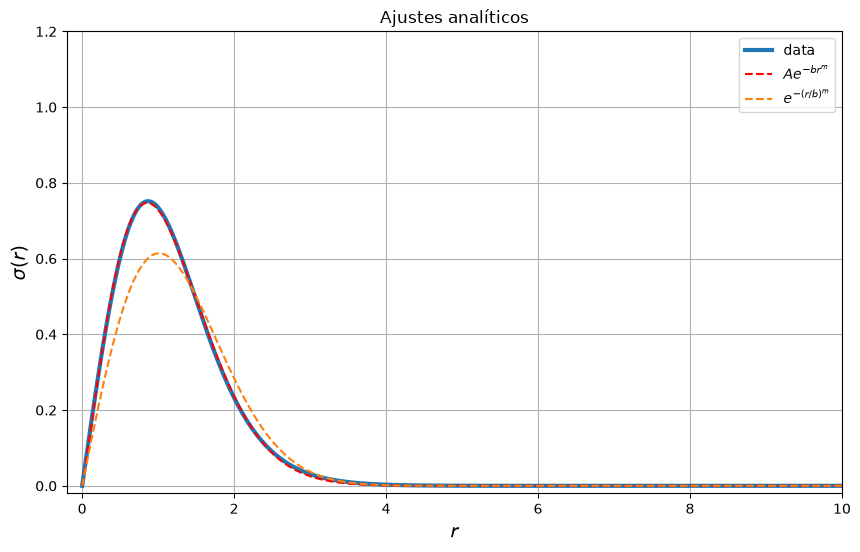

In [120]:
plt.figure(figsize=(10,6))

plt.plot(r, perfil,
         linewidth=3,
         label="data")

#plt.plot(r, fit_exp, '--', label=r'$Ar e^{-br}$')

#plt.plot(r, fit_gauss, '--', label=r'$Ar e^{-br^2}$')

plt.plot(r, fit_general, 'r--', label=r'$Ae^{-br^m}$')
plt.plot(r, fit_restricted, '--', label=r'$e^{-(r/b)^m}$')

plt.xlim(-0.2,10)
plt.ylim(-0.02, 1.2)

#plt.xlim(2, 4)
#plt.ylim(-0.05, 0.2)

plt.xlabel(r"$r$", fontsize=14)
plt.ylabel(r"$\sigma(r)$", fontsize=14)

plt.title("Ajustes analíticos")

plt.grid(True)

plt.legend()

plt.show()


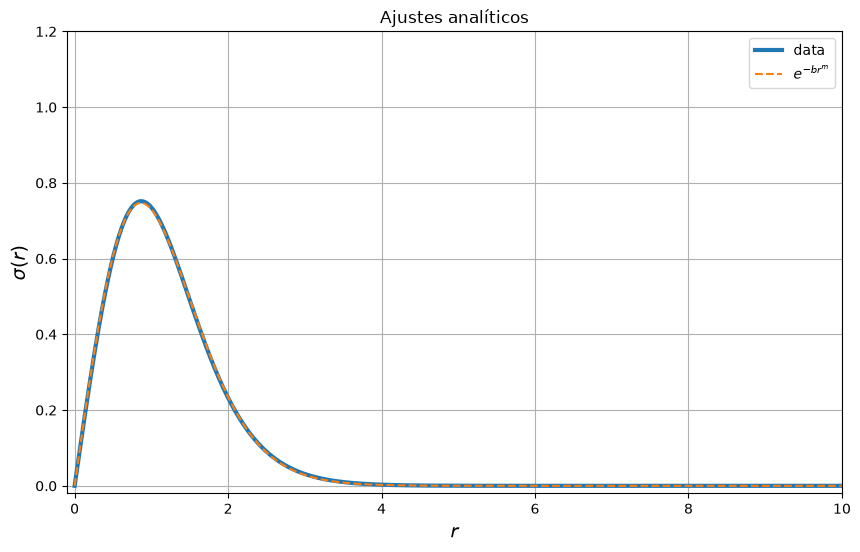

In [12]:
plt.figure(figsize=(10,6))

plt.plot(r, perfil, linewidth=3, label="data")

#plt.plot(r, fit_exp, '--', label=r'$Ae^{-br}$')

#plt.plot(r, fit_restricted, 'g--', label=r'$Ae^{-br^2}$')
plt.plot(r, fit_restricted, '--', label=r'$e^{-br^m}$')
#plt.plot(r, fit_general, '--', label=r'$Ar^n e^{-br^m}$')

plt.xlim(-0.1,10)
plt.ylim(-0.02, 1.2)

plt.xlabel(r"$r$", fontsize=14)
plt.ylabel(r"$\sigma(r)$", fontsize=14)

plt.title("Ajustes analíticos")

plt.grid(True)

plt.legend()

plt.show()


In [13]:
from scipy.interpolate import UnivariateSpline

# Crear la interpolación (ajustando un poco el suavizado)
phi_spline = UnivariateSpline(r, perfil, s=0.05, ext='zeros')
# s controla el suavizado; ajústalo según tu ruido

# Función de densidad interpolada
def rho_interp(x):
    return phi_spline(x)**2 if x <= r.max() else 0.0

In [14]:
from scipy.interpolate import CubicSpline

phi_num = CubicSpline(r, perfil, extrapolate=False)

rho_num = lambda x: phi_num(x)**2

In [15]:
def model_general(r, A, b, n, m):
    return A * r**n * np.exp(-b*r**m)
    #return A * np.exp(-b*r**m)

In [16]:
def phi_fit(r):
    return model_general( r, *popt_general)


In [17]:
def rho_fit(r):
    return phi_fit(r)**2

In [ ]:
a=1.0160
r_c = 2.296

def phi_ref(r):
    return np.sqrt(a)*(1 + ( r / r_c )**2)**-4
    #return model_restricted(r, popt_restricted)

In [76]:
def rho_ref(r):
    return phi_ref(r)**2

In [18]:
def model_restricted(r, A, b, n, m):
    return A*r*(1 + (r / b)**2)**m

In [19]:
def phi_ref(r):
    return model_restricted(r, *popt_restricted)

In [20]:
def rho_ref(r):
    return phi_ref(r)**2

In [102]:
def phi_restricted(r):
    return model_restricted(r, *popt_restricted)

In [103]:
def rho_rest(r):
    return phi_restricted(r)**2

# Gráfica del Campo Numérico, Analítico y Referencia.

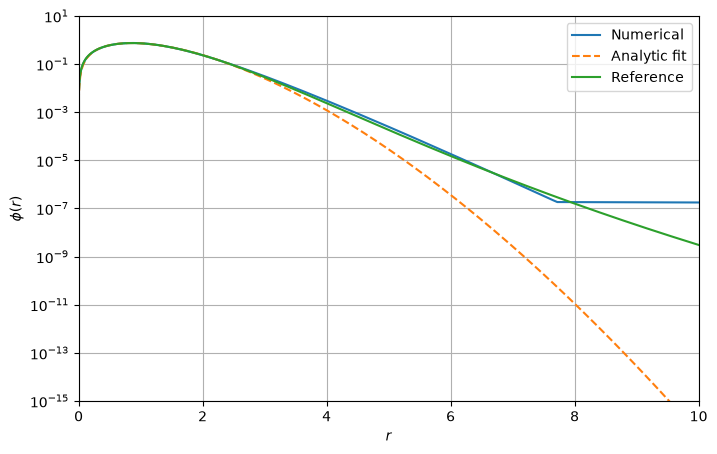

In [21]:
plt.figure(figsize=(8,5))

plt.semilogy(r, perfil, label='Numerical')

plt.semilogy(r, phi_fit(r), '--', label='Analytic fit')

plt.semilogy(r, phi_ref(r), label='Reference')


#plt.plot(r, phi_restricted(r), label='Restricted')

plt.ylim(10**(-15), 10**1)
plt.xlim(0, 10)

plt.xlabel(r'$r$')
plt.ylabel(r'$\phi(r)$')

plt.legend()
plt.grid()
plt.show()

No correr la de abajo

In [31]:
from scipy.interpolate import CubicSpline
from scipy.optimize import brentq

rho_num = perfil**2

rho_0 = rho_num[0]

rho_num_interp = CubicSpline(r, rho_num)

def f_rc(x):
    return rho_num_interp(x) - rho_0/(2**8)

r_c = brentq(f_rc, r[0], r[-1])

print("rho_0 =", rho_0)
print("r_c =", r_c)

rho_0 = 1.0
r_c = 2.2963291444707505


In [32]:
print("rho(0) =", rho_0)
print("rho(rc) =", rho_num_interp(r_c))
print("rho(0)/2 =", rho_0/2**8)

rho(0) = 1.0
rho(rc) = 0.003906249999994289
rho(0)/2 = 0.00390625


In [22]:
r_dense = np.linspace(r.min(), r.max(), 2000)

rho_num_dense = rho_num(r_dense)

rho_fit_dense = rho_fit(r_dense)

res_abs = rho_num_dense - rho_fit_dense

In [23]:
r_dense1 = np.linspace(r.min(), r.max(), 2000)

rho_fit_dense = rho_fit(r_dense1)

rho_ref_dense = rho_ref(r_dense1)

res_abs = rho_fit_dense - rho_ref_dense

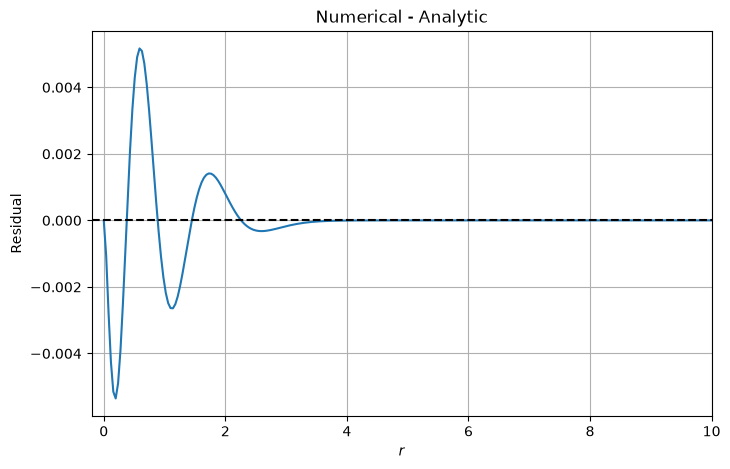

In [24]:
eps = 1e-12

res_rel = (rho_num_dense-rho_fit_dense)/( np.abs(rho_num_dense)+eps)

plt.figure(figsize=(8,5))

plt.plot(r_dense, res_abs)

plt.axhline(0, color='k', ls='--')

plt.xlabel(r"$r$")
plt.ylabel("Residual")
plt.xlim(-0.2, 10)

plt.title("Numerical - Analytic")

plt.grid()

plt.show()

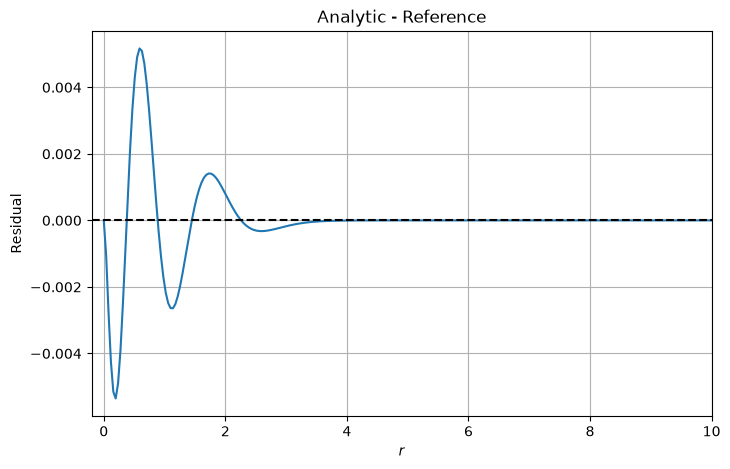

In [36]:
eps = 1e-12

res_rel = (rho_num_dense-rho_ref_dense)/( np.abs(rho_num_dense)+eps)

plt.figure(figsize=(8,5))

plt.plot(r_dense, res_abs)

plt.axhline(0, color='k', ls='--')

plt.xlabel(r"$r$")
plt.ylabel("Residual")
plt.xlim(-0.2, 10)

plt.title("Analytic - Reference")

plt.grid()

plt.show()

pendiente = 0.9969879240205182
intercepto = 2.2084916838625325e-05
R = 0.999897545703028


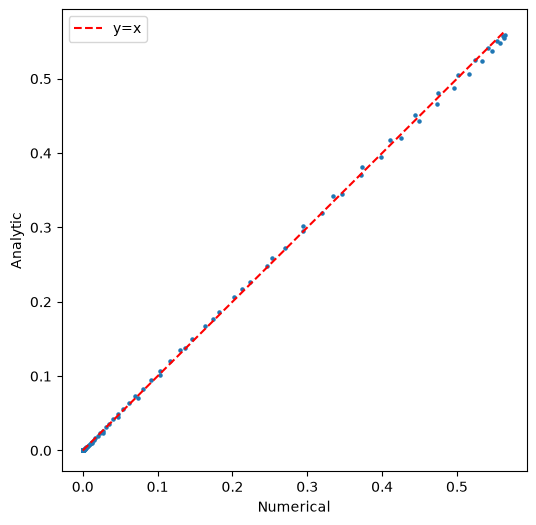

In [26]:
from scipy.stats import linregress

slope, intercept, rvalue, _, _ = linregress(
    rho_num_dense,
    rho_fit_dense
)

print("pendiente =",slope)
print("intercepto =",intercept)
print("R =",rvalue)

plt.figure(figsize=(6,6))

plt.scatter(
    rho_num_dense,
    rho_fit_dense,
    s=5
)

x=np.linspace(
    rho_num_dense.min(),
    rho_num_dense.max(),
    100
)

plt.plot(
    x,
    x,
    'r--',
    label='y=x'
)

plt.xlabel("Numerical")

plt.ylabel("Analytic")

plt.legend()

plt.show()

In [ ]:
print("Número de puntos:", len(r))
print("r mínimo:", r.min())
print("r máximo:", r.max())
print("dr promedio:", np.mean(np.diff(r)))

Número de puntos: 7947914
r mínimo: 0.0
r máximo: 79.47913000000001
dr promedio: 1e-05


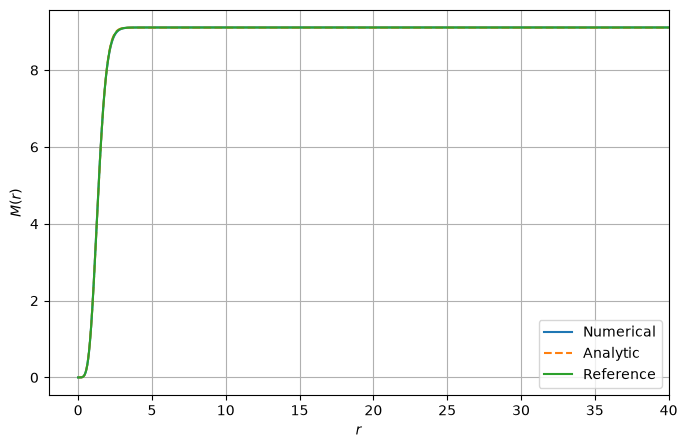

In [27]:
from scipy.integrate import cumulative_trapezoid
from scipy.optimize import brentq

mass_num = 4*np.pi*cumulative_trapezoid(
    perfil**2*r**2, r, initial=0)

mass_fit = 4*np.pi*cumulative_trapezoid(
    rho_fit(r)*r**2, r, initial=0)

mass_ref = 4*np.pi*cumulative_trapezoid(
    rho_ref(r)*r**2, r, initial=0)

#mass_rest = 4*np.pi*cumulative_trapezoid(
#    rho_rest(r)*r**2, r, initial=0)

plt.figure(figsize=(8,5))

plt.plot( r, mass_num, label='Numerical')

plt.plot(r, mass_fit, '--', label='Analytic')

plt.plot(r, mass_ref, label='Reference')

#plt.plot(r, mass_rest, label='Restricted')

plt.xlabel(r"$r$")

plt.ylabel(r"$M(r)$")
plt.xlim(-2, 40)

plt.legend()

plt.grid()

plt.show()

In [28]:
M_tot = mass_ref[-1]
m99_ref=0.99*M_tot
m95_ref=0.95*M_tot
m90_ref=0.90*M_tot

print(m99_ref , m95_ref, m90_ref)

i = np.argmin(np.abs(mass_ref - m95_ref))

R_95 = r[i]

print(R_95)


9.01758853767292 8.65324152604977 8.197807761520835
2.2137100000000003


In [29]:
from scipy.interpolate import CubicSpline
from scipy.optimize import brentq

mass_ref_interp = CubicSpline(r, mass_ref)

M_tot = mass_ref[-1]

def radio_porcentaje(p):
    return brentq(
        lambda x: mass_ref_interp(x) - p*M_tot,
        r[0],
        r[-1]
    )

R90 = radio_porcentaje(0.90)
R95 = radio_porcentaje(0.95)
R99 = radio_porcentaje(0.99)

print("R90 =", R90)
print("R95 =", R95)
print("R99 =", R99)

R90 = 1.998718615729561
R95 = 2.213711145256239
R99 = 2.651446475227852


In [30]:
from scipy.interpolate import CubicSpline
from scipy.optimize import brentq

def radios_masa(r, mass):
    
    # Masa total
    M_tot = mass[-1]
    
    # Interpolación de la masa acumulada
    mass_interp = CubicSpline(r, mass)
    
    # Función para encontrar el radio correspondiente a un porcentaje
    def radio_porcentaje(p):
        return brentq(
            lambda x: mass_interp(x) - p*M_tot,
            r[0],
            r[-1]
        )
    
    # Radios 90%, 95% y 99%
    R90 = radio_porcentaje(0.90)
    R95 = radio_porcentaje(0.95)
    R99 = radio_porcentaje(0.99)
    
    return R90, R95, R99

In [31]:
R90_num, R95_num, R99_num = radios_masa(r, mass_num)

R90_fit, R95_fit, R99_fit = radios_masa(r, mass_fit)

R90_ref, R95_ref, R99_ref = radios_masa(r, mass_ref)

In [32]:
print("Perfil numérico:")
print("R90 =", R90_num)
print("R95 =", R95_num)
print("R99 =", R99_num)

print("\nPerfil ajustado:")
print("R90 =", R90_fit)
print("R95 =", R95_fit)
print("R99 =", R99_fit)

print("\nPerfil de referencia:")
print("R90 =", R90_ref)
print("R95 =", R95_ref)
print("R99 =", R99_ref)

Perfil numérico:
R90 = 2.0048134403887166
R95 = 2.22860125586321
R99 = 2.690416379115469

Perfil ajustado:
R90 = 1.9924758763139798
R95 = 2.1991806068676083
R99 = 2.6070559403017852

Perfil de referencia:
R90 = 1.998718615729561
R95 = 2.213711145256239
R99 = 2.651446475227852


In [33]:
def error_relativo(valor, referencia):
    return abs((valor - referencia) / referencia) * 100

In [34]:
error_R90_fit = error_relativo(R90_fit, R90_num)
error_R95_fit = error_relativo(R95_fit, R95_num)
error_R99_fit = error_relativo(R99_fit, R99_num)

error_R90_ref = error_relativo(R90_ref, R90_num)
error_R95_ref = error_relativo(R95_ref, R95_num)
error_R99_ref = error_relativo(R99_ref, R99_num)

print("Errores del ajuste respecto al numérico:")
print("R90:", error_R90_fit, "%")
print("R95:", error_R95_fit, "%")
print("R99:", error_R99_fit, "%")

print("\nErrores de la referencia respecto al numérico:")
print("R90:", error_R90_ref, "%")
print("R95:", error_R95_ref, "%")
print("R99:", error_R99_ref, "%")

Errores del ajuste respecto al numérico:
R90: 0.6153971150724423 %
R95: 1.3201396579221674 %
R99: 3.098421473373963 %

Errores de la referencia respecto al numérico:
R90: 0.3040095669936109 %
R95: 0.6681370464005935 %
R99: 1.448471106187258 %


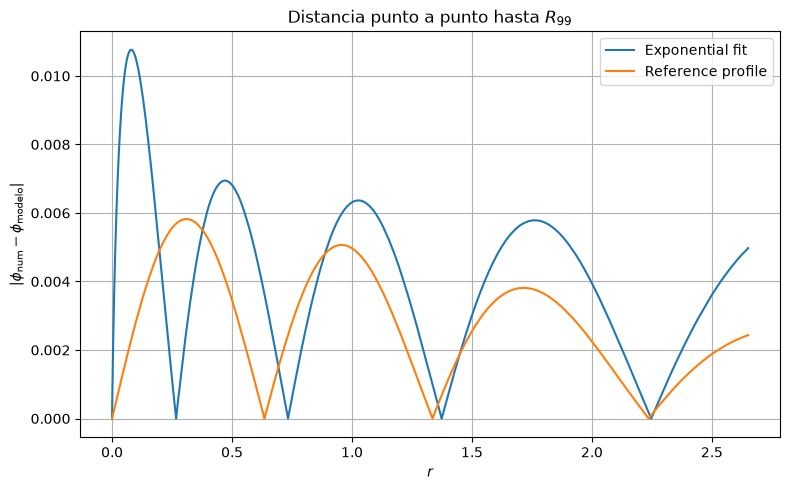

In [74]:

# Nos quedamos únicamente hasta R99
mask = r <= R99

r_R99 = r[mask]
num_R99 = perfil[mask]
fit_R99 = phi_fit(r)[mask]
ref_R99 = phi_ref(r)[mask]

# Distancia punto a punto respecto al perfil numérico
dist_fit = np.abs(num_R99 - fit_R99)
dist_ref = np.abs(num_R99 - ref_R99)


# Gráfica
plt.figure(figsize=(8, 5))

plt.plot(r_R99, dist_fit, label='Exponential fit')
plt.plot(r_R99, dist_ref, label='Reference profile')

plt.xlabel(r'$r$')
plt.ylabel(r'$|\phi_{\rm num}-\phi_{\rm modelo}|$')
plt.title(r'Distancia punto a punto hasta $R_{99}$')

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

C:\Users\SEARS\AppData\Local\Temp\ipykernel_4756\3901591993.py:1: RuntimeWarning: invalid value encountered in divide
  eps_fit = 100 * np.abs(num_R99 - fit_R99) / np.abs(num_R99)
C:\Users\SEARS\AppData\Local\Temp\ipykernel_4756\3901591993.py:2: RuntimeWarning: invalid value encountered in divide
  eps_ref = 100 * np.abs(num_R99 - ref_R99) / np.abs(num_R99)


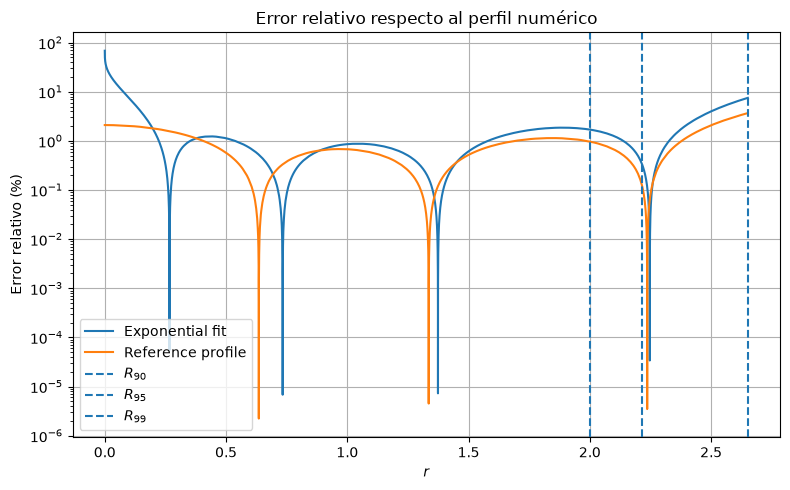

In [77]:
eps_fit = 100 * np.abs(num_R99 - fit_R99) / np.abs(num_R99)
eps_ref = 100 * np.abs(num_R99 - ref_R99) / np.abs(num_R99)

plt.figure(figsize=(8, 5))

plt.plot(r_R99, eps_fit, label='Exponential fit')
plt.plot(r_R99, eps_ref, label='Reference profile')

plt.axvline(R90, linestyle='--', label=r'$R_{90}$')
plt.axvline(R95, linestyle='--', label=r'$R_{95}$')
plt.axvline(R99, linestyle='--', label=r'$R_{99}$')

plt.xlabel(r'$r$')
plt.ylabel('Error relativo (%)')
plt.title('Error relativo respecto al perfil numérico')

plt.yscale('log')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

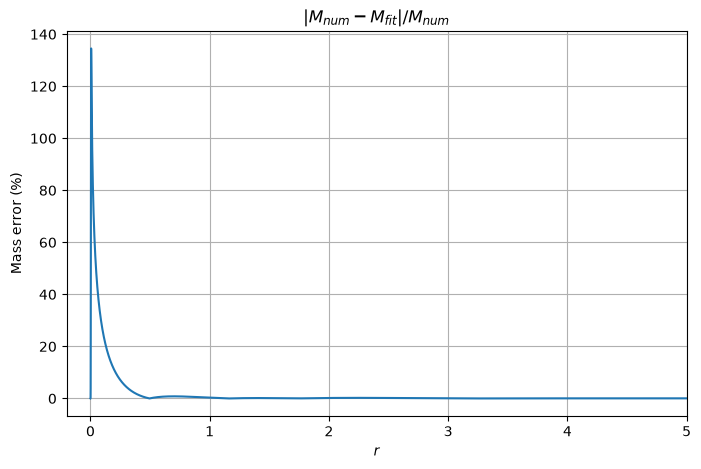

In [35]:
eps = 1e-12

#mass_rel_error = (mass_num - mass_fit) / (mass_num + eps)
mass_rel_error = (mass_fit - mass_ref) / (mass_fit + eps)

plt.figure(figsize=(8,5))

plt.plot(r, 100*np.abs(mass_rel_error))

plt.xlabel(r"$r$")
plt.ylabel("Mass error (%)")
plt.xlim(-0.2,5)

plt.title(r"$|M_{num}-M_{fit}|/M_{num}$")

plt.grid()

plt.show()

In [41]:
M_num_total = mass_num[-1]
M_fit_total = mass_fit[-1]
M_ref_total = mass_ref[-1]

error_total = abs(
    M_num_total - M_fit_total
)/M_num_total

error_total2 = abs(M_num_total - M_ref_total)/M_num_total

print(
    "Error masa total (Num vs Fit)=",
    100*error_total,
    "%"
)
print("Error masa total (Num vs Ref)=", 100*error_total2, "%")

Error masa total (Num vs Fit)= 0.05747707436640999 %
Error masa total (Num vs Ref)= 0.017436449625968336 %


In [ ]:
M_fit_total = mass_fit[-1]
M_ref_total = mass_ref[-1]

error_total = abs(
    M_fit_total - M_ref_total
)/M_fit_total

print(
    "Error masa total =",
    100*error_total,
    "%"
)

Error masa total = 0.040063652155585015 %


In [42]:
def sigma_generic(xi, rho_func, zmax=6):
    
    integrand = lambda z: rho_func(
        np.sqrt(xi**2 + z**2))
    
    result, _ = quad(integrand, 0, zmax, epsabs=1e-6, epsrel=1e-6)
    
    return 2*result

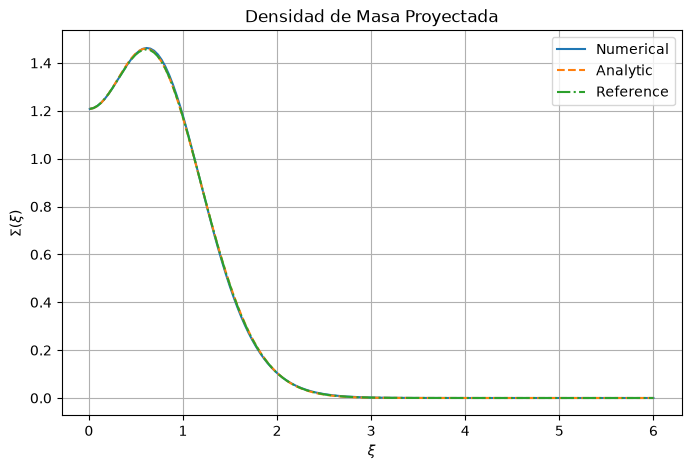

In [43]:
xi_vals = np.linspace(0.01, 6, 150)

sigma_num_vals = np.array([sigma_generic(xi, rho_num, zmax=6) for xi in xi_vals])
sigma_fit_vals = np.array([sigma_generic(xi, rho_fit, zmax=6) for xi in xi_vals])
sigma_ref_vals = np.array([sigma_generic(xi, rho_ref, zmax=6) for xi in xi_vals])

plt.figure(figsize=(8,5))

plt.plot(
    xi_vals,
    sigma_num_vals,
    label="Numerical"
)

plt.plot(
    xi_vals,
    sigma_fit_vals,
    '--',
    label="Analytic"
)

plt.plot(
    xi_vals,
    sigma_ref_vals,
    '-.',
    label="Reference"
)

plt.xlabel(r'$\xi$')
plt.ylabel(r'$\Sigma(\xi)$')
plt.title(r'Densidad de Masa Proyectada')

plt.legend()
plt.grid()

plt.show()

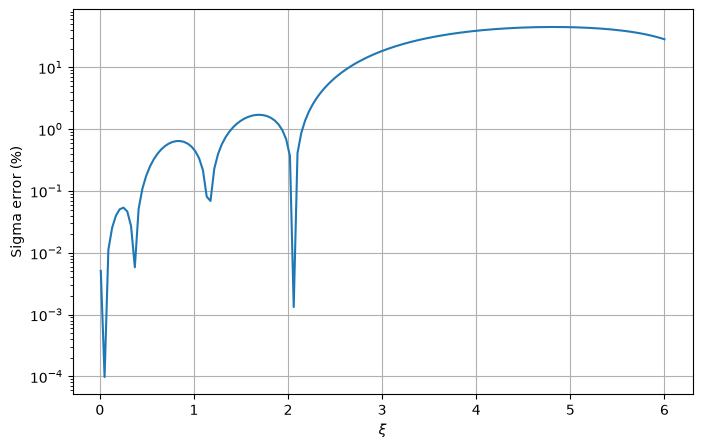

In [45]:
sigma_error = np.abs(
    sigma_num_vals - sigma_ref_vals)/(np.abs(sigma_num_vals)+1e-12)

plt.figure(figsize=(8,5))

plt.semilogy(
    xi_vals,
    100*sigma_error
)

plt.xlabel(r'$\xi$')
plt.ylabel("Sigma error (%)")

plt.grid()

plt.show()

In [46]:
m_num_vals = (2*np.pi*
    cumulative_trapezoid(xi_vals*sigma_num_vals, xi_vals, initial=0))

m_fit_vals = (2*np.pi*
    cumulative_trapezoid(xi_vals*sigma_fit_vals, xi_vals, initial=0))
m_ref_vals = (2*np.pi*
    cumulative_trapezoid(xi_vals*sigma_fit_vals, xi_vals, initial=0))

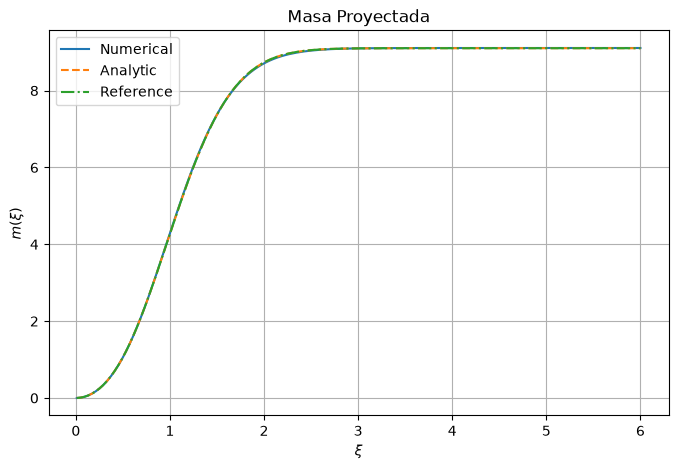

In [47]:
plt.figure(figsize=(8,5))

plt.plot(xi_vals, m_num_vals, label="Numerical")

plt.plot(xi_vals, m_fit_vals, '--', label="Analytic")

plt.plot(xi_vals, m_ref_vals, '-.', label="Reference")

plt.xlabel(r'$\xi$')
plt.ylabel(r'$m(\xi)$')

plt.title(r'Masa Proyectada')

plt.legend()
plt.grid()

plt.show()

In [48]:
m_num_interp = CubicSpline(xi_vals, m_num_vals)

m_fit_interp = CubicSpline(xi_vals, m_fit_vals)

m_ref_interp = CubicSpline(xi_vals, m_ref_vals)

lambda_bar = 0.30

In [49]:
def m_generic(xi, rho_func):
    
    integrand = lambda x: (x * sigma_generic(x, rho_func))
    
    result, _ = quad(integrand, 0, xi, limit=200)
    
    return 2*np.pi*result

In [50]:
def beta(theta, lambda_bar, m_interp):
    return theta - lambda_bar * m_interp(abs(theta)) / theta

In [51]:
theta_vals = np.linspace(0.01, 6, 500)

beta_num_vals = np.array([beta(th, lambda_bar, m_num_interp) for th in theta_vals])

beta_fit_vals = np.array([beta(th, lambda_bar, m_fit_interp) for th in theta_vals])

beta_ref_vals = np.array([beta(th, lambda_bar, m_ref_interp) for th in theta_vals])

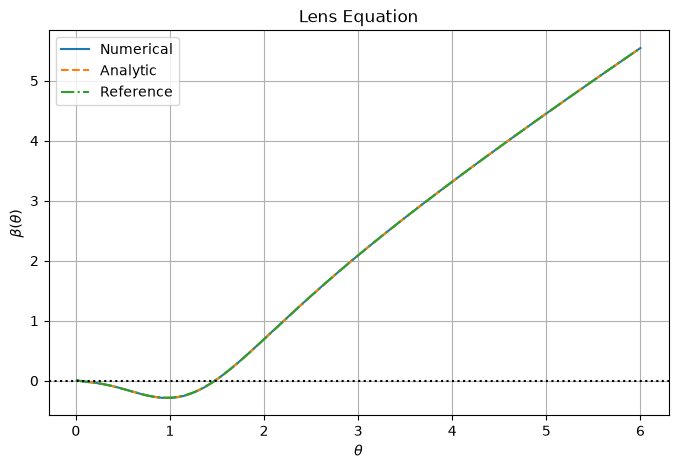

In [52]:
plt.figure(figsize=(8,5))

plt.plot(
    theta_vals,
    beta_num_vals,
    label='Numerical'
)

plt.plot(
    theta_vals,
    beta_fit_vals,
    '--',
    label='Analytic'
)

plt.plot(
    theta_vals,
    beta_ref_vals,
    '-.',
    label="Reference"
)

plt.axhline(
    0,
    color='k',
    ls=':'
)

plt.xlabel(r'$\theta$')

plt.ylabel(r'$\beta(\theta)$')


plt.title('Lens Equation')

plt.legend()

plt.grid()

plt.show()

In [53]:
def einstein_radius(lambda_bar, m_interp, theta_min=0.01, theta_max=10):
    
    f = lambda theta: beta(theta, lambda_bar, m_func)
    
    theta_grid = np.linspace(theta_min, theta_max, 500)
    
    beta_grid = np.array([
        beta(th, lambda_bar, m_interp) for th in theta_grid])

    sign_change = np.where(
        beta_grid[:-1]*
        beta_grid[1:] < 0
    )[0]

    if len(sign_change)==0:
        return None

    i = sign_change[0]

    return brentq(
        lambda th:
        beta(
            th,
            lambda_bar,
            m_interp
        ),
        theta_grid[i],
        theta_grid[i+1]
    )

In [54]:


thetaE_num = einstein_radius(lambda_bar, m_num_interp)

thetaE_fit = einstein_radius(lambda_bar, m_fit_interp)

thetaE_ref = einstein_radius(lambda_bar, m_ref_interp)

In [57]:
print(thetaE_num)
print(thetaE_fit)
print(thetaE_ref)

theta_error = abs(
    thetaE_num-thetaE_fit
)/abs(thetaE_num)

theta_error2 = abs(
    thetaE_num - thetaE_ref
)/abs(thetaE_num)

print(
    "Einstein radius error (Num vs Fit) =",
    100*theta_error, "%"
)
print(
    "Eisntein radius error (Num vs Ref) =", 
    100*theta_error2, "%"
)

0.02837108854486294
0.02838671580589188
0.02838671580589188
Einstein radius error (Num vs Fit) = 0.0550816406082938 %
Eisntein radius error (Num vs Ref) = 0.0550816406082938 %


In [60]:
mass_proj_error = np.abs(
    m_num_vals-m_ref_vals)/(np.abs(m_num_vals)+1e-12)

print(
    "Maximum projected mass error (%) =",
    100*np.max(
        mass_proj_error[1:]
    )
)

print(
    "Mean projected mass error (%) =",
    100*np.mean(
        mass_proj_error[1:]
    )
)

Mproj_num = m_num_vals[-1]

Mproj_ref = m_ref_vals[-1]

proj_total_error = abs(
    Mproj_num-Mproj_ref
)/abs(
    Mproj_num
)

print(
    "Projected mass total error (%) =",
    100*proj_total_error
)

Maximum projected mass error (%) = 0.38555255044257286
Mean projected mass error (%) = 0.10650530617125215
Projected mass total error (%) = 0.05747563584344419


C:\Users\SEARS\AppData\Local\Temp\ipykernel_4756\2964421299.py:2: RuntimeWarning: invalid value encountered in divide
  error_rel = (m_num_vals - m_ref_vals) / m_num_vals


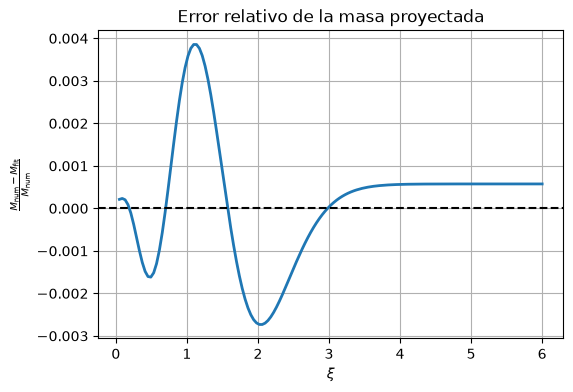

In [61]:
# Error relativo punto a punto
error_rel = (m_num_vals - m_ref_vals) / m_num_vals

plt.figure(figsize=(6,4))
plt.plot(xi_vals, error_rel, lw=2)
plt.axhline(0, color='k', ls='--')

plt.xlabel(r'$\xi$')
plt.ylabel(r'$\frac{M_{\rm num}-M_{\rm fit}}{M_{\rm num}}$')
plt.title('Error relativo de la masa proyectada')
plt.grid(True)

plt.show()

In [62]:
beta_diff = (beta_num_vals - beta_ref_vals)

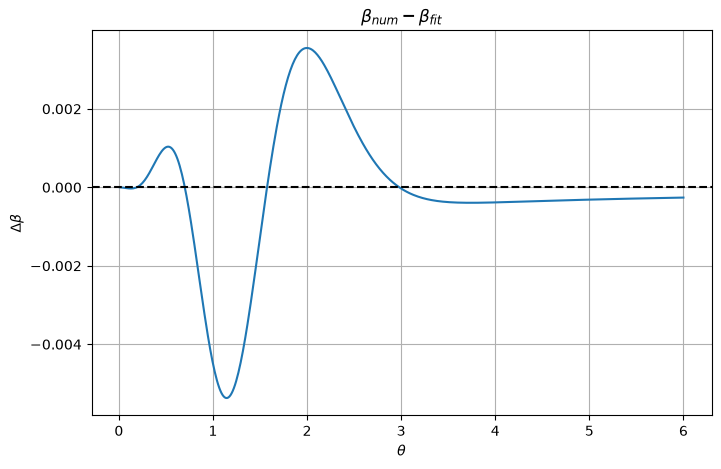

In [63]:
plt.figure(figsize=(8,5))

plt.plot(theta_vals, beta_diff)

plt.axhline(0, color='k', ls='--')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$\Delta\beta$')

plt.title(r'$\beta_{num}-\beta_{fit}$')

plt.grid()
plt.show()